### Building a basic chatbot using langgraph(Graph API)

#### Core Building Blocks
* State: The shared memory or data structure that holds the current snapshot of your application. It updates as data flows through the workflow.
* Nodes: Python or JavaScript functions that do the actual work. They take the current state, run logic (like calling an LLM or a tool), and return an updated state.
* Edges: The pathways that connect nodes and decide the execution order.
* Conditional Edges: Special decision points that look at the current state to choose which node should run next. 
* START and END: Built-in markers that show where the graph workflow begins and finishes

# Basic LangGraph Building Blocks (YouTube Video → Blog Workflow)

In this example, we build a workflow that converts a **YouTube video into a blog**. The workflow consists of three main tasks:

1. **YouTube URL → Transcript**
2. **Transcript → Title**
3. **Transcript + Title → Blog Content**

LangGraph represents this workflow using four fundamental building blocks: **State, Nodes, Edges, and Graph**.

---

## 1. State

The **State** is the shared memory of the workflow. It stores all the information generated during execution. Every node reads the required values from the state, performs its task, updates the state, and passes it to the next node.

For this workflow, the state may look like:

```python
State = {
    "youtube_url": "...",
    "transcript": "...",
    "title": "...",
    "content": "..."
}
```

As the workflow progresses:
- Initially, only `youtube_url` is available.
- The Transcript node adds `transcript`.
- The Title Generator node adds `title`.
- The Content Generator node adds `content`.

Thus, the state acts as the **single source of truth** shared across all nodes.

---

## 2. Nodes

A **Node** is an individual unit of work that performs a specific task. It can call an LLM, invoke a tool, process data, or execute any custom Python function.

In this workflow, there are three nodes:

- **Transcript Node**
  - Input: YouTube URL
  - Output: Transcript

- **Title Generator Node**
  - Input: Transcript
  - Output: Title

- **Content Generator Node**
  - Input: Transcript + Title
  - Output: Blog Content

Each node performs one well-defined responsibility and updates the shared state.

---

## 3. Edges

An **Edge** connects two nodes and determines the execution flow. It tells LangGraph which node should execute next after the current node finishes.

For this example, the edges are:

```
START
  ↓
Transcript Node
  ↓
Title Generator Node
  ↓
Content Generator Node
  ↓
END
```

Here, the output of one node becomes the input for the next through the shared state.

---

## 4. StateGraph

A **StateGraph** is the complete workflow created by connecting multiple nodes using edges. It defines the overall execution path from the initial input to the final output. We call it StateGraph since its able to maintain the context(State) throughout the entire graph

Our complete graph is:

```
YouTube URL
      │
      ▼
Transcript Node
      │
      ▼
Title Generator Node
      │
      ▼
Content Generator Node
      │
      ▼
Generated Blog
```

The graph orchestrates the execution by ensuring that each node runs in the correct order and has access to the required data from the shared state.

---

## Summary

| Component | Purpose | Example in this Workflow |
|-----------|---------|--------------------------|
| **State** | Shared memory that stores data throughout execution | YouTube URL, Transcript, Title, Content |
| **Node** | A single task or operation | Transcript Generator, Title Generator, Content Generator |
| **Edge** | Defines the execution flow between nodes | Transcript → Title → Content |
| **StateGraph** | The complete workflow made by connecting nodes with edges | YouTube Video → Transcript → Title → Blog |

![Workflow](../Images/ytvideoTOblog_implementation_understanding_basicComponentsOfLangGraph0.png)
![Workflow](../Images/ytvideoTOblog_implementation_understanding_basicComponentsOfLangGraph1.png)

#### Workflow API's 
**Graph API:** The Graph API is the lower-level and more flexible way to build LangGraph workflows. You explicitly create nodes, connect them with edges, define routing logic, loops, and conditional paths, giving you full control over how the workflow executes. It is best suited for complex, production-grade agent systems.

**Functional API:** The Functional API is a higher-level, Pythonic way to build LangGraph workflows using regular functions and decorators. Instead of manually defining nodes and edges, you write the workflow as normal Python code while LangGraph handles the underlying graph construction and execution. It is simpler and ideal for straightforward workflows.

We would be learning **Graph API** first


In [7]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

from langgraph.graph.message import add_messages
# Messages have the type list and add_messages is a special reducer function in LangGraph that appends new messages to an existing list 
# instead of overwriting them, which helps maintain conversation history and state in a StateGraph.
# it uses ID's to save messages, if a new message has same ID as an existing message, it will overwrite the old message with the new one.



In [8]:
class State(TypedDict):
    messages: Annotated[list, add_messages]  # This field will hold the conversation messages, and new messages will be added to this list using the add_messages reducer.

graph_builder=StateGraph(State)
# This line initializes the structural blueprint of your AI workflow by creating an empty graph configuration 
# that uses your State class as its global memory layout. By passing State into StateGraph, you establish a single 
# source of truth that all future node functions will read from and write to, while simultaneously registering the 
# add_messages rule to ensure your conversation logs automatically append new history instead of overwriting it

In [9]:
graph_builder

In [10]:
import os
from dotenv import load_dotenv
load_dotenv()  # Load environment variables from a .env file if present



True

In [ ]:
from langchain_groq import ChatGroq # WAY 1 to import the ChatGroq model from the langchain_groq package. This is a specialized chat model that leverages Groq's capabilities for conversational AI tasks.
from langchain.chat_models import init_chat_model # WAY 2 to import the init_chat_model function from the langchain.chat_models module. This function is a more general approach to initializing chat models, allowing for flexibility in choosing different model backends, including Groq.

llm = init_chat_model(
    "groq:llama-3.3-70b-versatile",
    )
llm




ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F144446900>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F144447620>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [12]:
### Creating node definition or node functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [13]:
# creating a graph using GRAPH API
graph_builder=StateGraph(State)

# adding node
graph_builder.add_node("llmchatbot",chatbot)

# adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

# compile the graph
graph=graph_builder.compile()


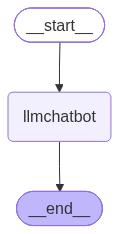

In [17]:
# visualize the graph
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)


In [ ]:
### invoking the chatbot
response=graph.invoke({"messages":"can you tell what is AI exactly in 1 line"})
response["messages"]



# earlier in the node functionality we had specified the llm to take input from 'messages' dictionary(dict named messages) therefore here we passed a dictionary of name messages with "Hi" in it
# "Hi" would be treated as a human message, and respinse is with respect to the ai message

'Artificial Intelligence (AI) is a computer system that can perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making.'

#### Streaming
Streaming means receiving results as they are produced, instead of waiting for the entire graph to finish.

* invoke() → Wait until the graph completes, then return the final state.
* stream() → Return each node's output immediately after that node executes.

Think of it like this:

* invoke() = Watch the completed movie after it's finished.
* stream() = Watch the movie live as each scene happens.

Langchain's stream is different, it's work is to display the tokens generated by the llm as soon as they are generated, not once the whole repsonse is generated, langgraphs stream is different

In [ ]:
for event in graph.stream({"messages":"can you tell how to reduce llm cost exactly in 1 line"}):
    print(event)

for event in graph.stream({"messages":"can you tell how to reduce llm cost exactly in 1 line"}):
    for value in event.values():
        print(value)

''' 
In this graph, there is only one node (llmchatbot), so graph.stream() emits only one event—the output of that node.
 If we added more nodes (e.g., a tool node, retriever node, summarizer node), stream() would emit an event after each node completes. 
 For example:
 {'retriever': {...}}
{'tool': {...}}
{'llmchatbot': {...}}
 '''

'''
The first loop prints the entire event dictionary, which includes both the node name (llmchatbot) and the 
state update returned by that node, for example {'llmchatbot': {'messages': [...]}}. The second loop iterates over 
event.values() and prints only the value (the state update), omitting the node name
'''

{'llmchatbot': {'messages': [AIMessage(content='To reduce LLM (Large Language Model) costs, optimize usage by batching requests, using smaller models, and implementing efficient caching mechanisms.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 49, 'total_tokens': 77, 'completion_time': 0.110659204, 'completion_tokens_details': None, 'prompt_time': 0.001664206, 'prompt_tokens_details': None, 'queue_time': 0.050962614, 'total_time': 0.11232341}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9aaa-fc7a-7d52-84e7-d2a92d8673a0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 28, 'total_tokens': 77})]}}
